# 01. Data Exploration and Loading

**Objective**: Load and explore audit quality data from Indonesian Stock Exchange

This notebook covers:
1. Loading data from Excel
2. Initial data exploration
3. Data quality assessment
4. Panel structure validation
5. Converting to JSON format

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.append('..')

from src.data.loader import DataLoader
from src.data.converter import ExcelToJSONConverter
from src.data.validator import DataValidator
from src.utils.config import ConfigManager

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Configuration

In [15]:
# Load configuration
config_manager = ConfigManager(config_dir='../config')
variables = config_manager.get_variable_info()

# Display variable information
print("Research Variables:")
print("\nDependent Variable:")
print(f"  {variables['dependent_variable']['name']}: {variables['dependent_variable']['full_name']}")

print("\nIndependent Variables:")
for var in variables['independent_variables']:
    print(f"  {var['name']}: {var['full_name']}")

print("\nControl Variables:")
for var in variables['control_variables']:
    print(f"  {var['name']}: {var['full_name']}")

Research Variables:

Dependent Variable:
  AQMS: Audit Quality Measurement Score

Independent Variables:
  ARL: Audit Report Lag
  FEE: Audit Fee
  FO: Foreign Ownership

Control Variables:
  SIZE: Company Size
  ROA: Return on Assets


## 2. Load Data from Excel

**Note**: Place your Excel file in `data/raw/` directory first!

In [16]:
# Initialize loader
loader = DataLoader()

# Load data (adjust filename as needed)
# Option 1: If you have the Excel file
data = loader.load_excel('../data/raw/audit_data.xlsx')

# Option 2: For testing with sample data
# Create sample data structure
# print("\nTo load your actual data, uncomment and run:")
# print("data = loader.load_excel('../data/raw/audit_data.xlsx')")
# print("\nExpected columns based on configuration:")
# expected_cols = [
#     variables['panel_structure']['entity_variable'],
#     variables['panel_structure']['time_variable'],
#     variables['dependent_variable']['name']
# ]
# expected_cols += [v['name'] for v in variables['independent_variables']]
# expected_cols += [v['name'] for v in variables['control_variables']]
# print(expected_cols)

Loading Excel file: ..\data\raw\audit_data.xlsx
Loaded 252 rows and 8 columns


## 3. Initial Data Exploration

Uncomment and run after loading your data

In [17]:
# After loading data, explore it:
print("\nData Shape:")
print(f"Rows: {len(data):,}, Columns: {len(data.columns)}")

print("\nColumn Names:")
print(data.columns.tolist())

print("\nFirst few rows:")
data.head()


Data Shape:
Rows: 252, Columns: 8

Column Names:
['AQMS', 'FEE', 'ARL', 'FO', 'SIZE', 'ROA', 'CODE', 'YEAR']

First few rows:


,AQMS,FEE,ARL,FO,SIZE,ROA,CODE,YEAR
0,2,24.20,3.95,0.00,24.14,0.06,AALI,2021
1,2,24.69,3.93,0.00,24.10,0.06,AALI,2022
2,2,25.14,3.93,0.00,24.09,0.04,AALI,2023
3,2,25.96,3.93,0.00,24.08,0.04,AALI,2024
4,2,19.34,4.49,0.92,27.90,0.20,ADES,2021


In [18]:
# Data types
print("\nData Types:")
data.dtypes


Data Types:


AQMS      int64
FEE     float64
ARL     float64
FO      float64
SIZE    float64
ROA     float64
CODE     object
YEAR      int64
dtype: object

In [19]:
# Basic statistics
print("\nDescriptive Statistics:")
data.describe()


Descriptive Statistics:


,AQMS,FEE,ARL,FO,SIZE,ROA,YEAR
count,252.00,252.00,252.00,252.00,252.00,252.00,252.00
mean,1.55,22.65,4.45,0.19,28.42,8.87,2022.50
std,1.07,1.65,0.26,0.28,2.05,244.18,1.12
min,0.00,17.45,3.81,0.00,17.98,-1391.15,2021.00
25%,1.00,21.48,4.39,0.00,27.26,0.01,2021.75
50%,1.00,22.51,4.47,0.00,28.56,0.05,2022.50
75%,3.00,23.86,4.49,0.42,29.65,0.10,2023.25
max,4.00,26.50,6.04,0.92,32.94,3612.44,2024.00


## 4. Data Quality Assessment

In [20]:
# Initialize validator
validator = DataValidator()

# Check missing values
missing_report = validator.check_missing_values(data, threshold=0.05)
missing_report


MISSING VALUE ANALYSIS

Total missing values: 0
Columns with missing values: 0/8

✓ No missing values detected


,column,n_missing,pct_missing,flag
0,AQMS,0,0.00,✓
1,FEE,0,0.00,✓
2,ARL,0,0.00,✓
3,FO,0,0.00,✓
4,SIZE,0,0.00,✓
5,ROA,0,0.00,✓
6,CODE,0,0.00,✓
7,YEAR,0,0.00,✓


## 5. Panel Structure Validation

In [21]:
# Validate panel structure
entity_col = variables['panel_structure']['entity_variable']
time_col = variables['panel_structure']['time_variable']

panel_report = validator.validate_panel_structure(data, entity_col, time_col)

print("\nPanel Type:", "Balanced" if panel_report['is_balanced'] else "Unbalanced")
print("Entities:", panel_report['n_entities'])
print("Time Periods:", panel_report['n_periods'])
print("Total Observations:", panel_report['n_observations'])


PANEL DATA STRUCTURE VALIDATION

Entities: 63
Time Periods: 4 [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total Observations: 252
Expected (balanced): 252
Panel Type: Balanced

✓ Panel structure is valid

Panel Type: Balanced
Entities: 63
Time Periods: 4
Total Observations: 252


## 6. Convert to JSON Format

In [ ]:
# Convert Excel to JSON for easier loading
converter = ExcelToJSONConverter()

converter.convert(
    excel_path='../data/raw/audit_data.xlsx',
    json_path='../data/processed/audit_data.json',
    include_metadata=False,  # Use simple flat JSON format (pandas-compatible)
    validate=True
)

print("\n✓ Data converted to JSON successfully!")

## 7. Variable Distributions (Visualization)

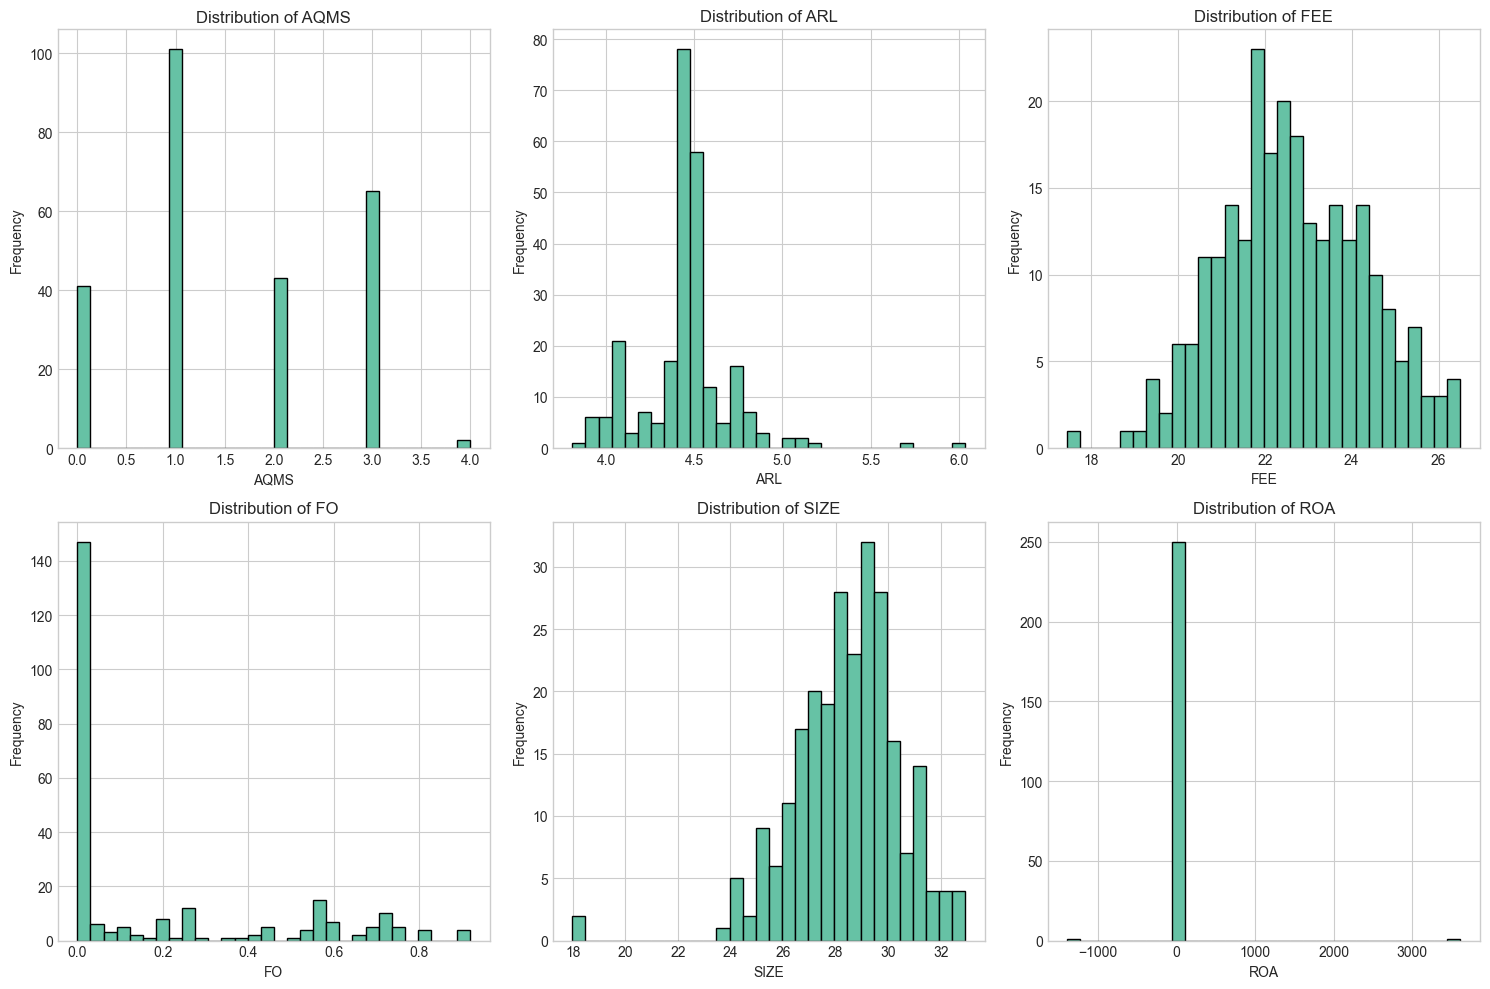

In [26]:
# Visualize distributions of key variables
numeric_cols = ['AQMS', 'ARL', 'FEE', 'FO', 'SIZE', 'ROA']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if col in data.columns:
        data[col].hist(bins=30, ax=axes[i], edgecolor='black')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:
- ✓ Loading data from Excel
- ✓ Data quality assessment
- ✓ Panel structure validation
- ✓ Converting to JSON format

**Next Steps**:
1. Run notebook `02_descriptive_stats.ipynb` for detailed descriptive analysis
2. Continue with diagnostic tests in `03_diagnostic_tests.ipynb`
3. Perform panel regression in `04_panel_data_analysis.ipynb`